In [1]:
import pandas as pd
# import scanpy as sc
import cafe

img_dir = "./img/25.12.31-figure1.C_viusalization"

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

In [2]:
fadata = cafe.data.read_dynverse_simulation_data()

# rename milestones 
milestone_old2new = {
    "M1": "A",
    "M3": "B",
    "M4": "C",
    "M2": "D",
}
mw = fadata.get_milestone_wrapper()
mw.rename_milestone(milestone_old2new)

# cluster: group cells onto nearest milestones
cluster = "group_onto_ref"
fadata.group_onto_nearest_milestones(cluster_key=cluster)

# milestone realated color
fadata.obs[cluster] = fadata.obs[cluster].astype("category")
fadata.uns[f"{cluster}_colors"] = list(map(lambda x: mw.milestone_color_dict[x], fadata.obs[cluster].cat.categories))

# basis: find better embedding
#  try to use tSNE/ UMAP on the raw data or transformed data
# basis = "X_tsne"
# sc.pp.normalize_total(fadata)
# sc.pp.log1p(fadata)
# sc.pp.highly_variable_genes(fadata, n_top_genes=1000)
# adata = fadata[:, fadata.var["highly_variable"]]
# sc.pp.pca(adata, n_comps=50)
# sc.tl.tsne(fadata)
# sc.pl.tsne(fadata, color=cluster)
# sc.pp.neighbors(fadata)
# sc.tl.umap(fadata)
# sc.pl.umap(fadata, color=cluster)
# directly use the provided embedding by dynverse
basis = "X_dynverse"
fadata.obsm[basis] = pd.read_csv("tmp/bifurcating_1_dimred.csv", index_col=0).values


prior_information = {
    "cluster": cluster,
    "basis": basis,
    "start_cell": "C445",
    "start_milestone": "A",
}
fadata.add_prior_information(**prior_information)

fadata.write_h5ad("tmp/dynverse_bifurcating_1.h5ad")
fadata

INFO     |- successfully renamed milestones: {'M1': 'A', 'M3': 'B', 'M4': 'C', 'M2': 'D'}                                                                                                               


AnnData object with n_obs × n_vars = 926 × 1128
    obs: 'c', 'group_onto_ref'
    var: 'feature_id', 'housekeeping'
    uns: 'id', 'cafe', 'group_onto_ref_colors'
    obsm: 'X_dynverse'
    layers: 'expression', 'counts'

array([[<Axes: title={'center': 'ref(milestone)'}, xlabel='_milestone_network_emb1', ylabel='_milestone_network_emb2'>]],
      dtype=object)

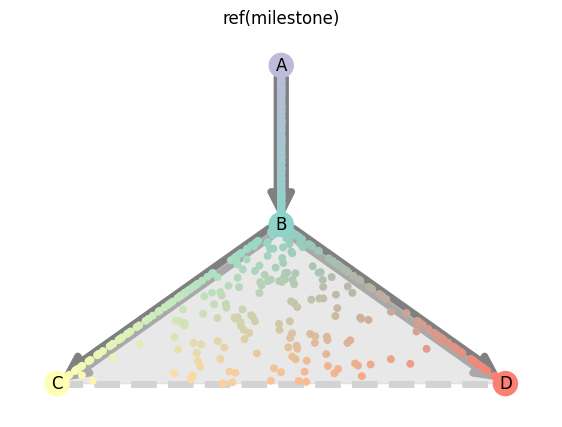

In [3]:
cafe.plot.plot_graph(fadata, color="milestone", save=f"{img_dir}/plot_graph.pdf")

array([[<Axes: title={'center': 'ref(group_onto_ref)'}, xlabel='X_dynverse1', ylabel='X_dynverse2'>]],
      dtype=object)

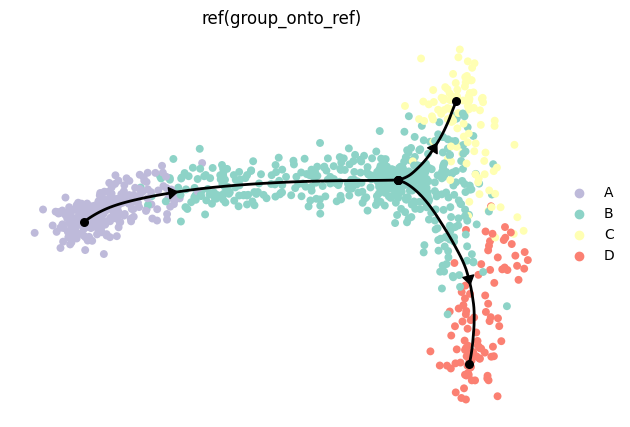

In [4]:
cafe.plot.plot_trajectory(fadata, save=f"{img_dir}/plot_trajectory.pdf")

INFO     |- Preparing FateAnnData for stream plotting (model: ref)                                                                                                                                      
INFO     |- FateAnnData prepared successfully for stream plotting                                                                                                                                       
INFO     |- Plotting stream_sc with color: ['group_onto_ref']                                                                                                                                           
INFO     |- Saved stream plot to './img/25.12.31-figure1.C_viusalization/plot_stream.pdf'                                                                                                               


[<Figure size 600x400 with 1 Axes>]

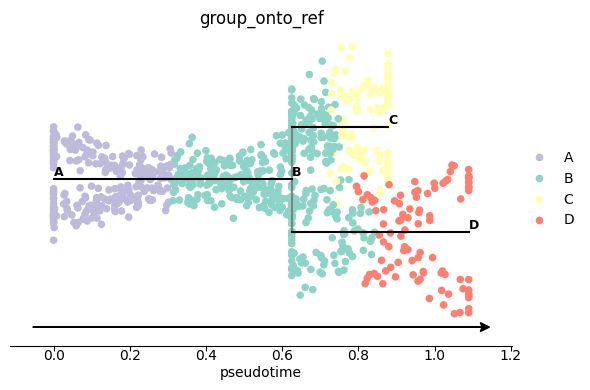

In [8]:
cafe.plot.plot_stream(fadata, mode="cell", save=f"{img_dir}/plot_stream.pdf", alpha=1, fig_size=(6,4))

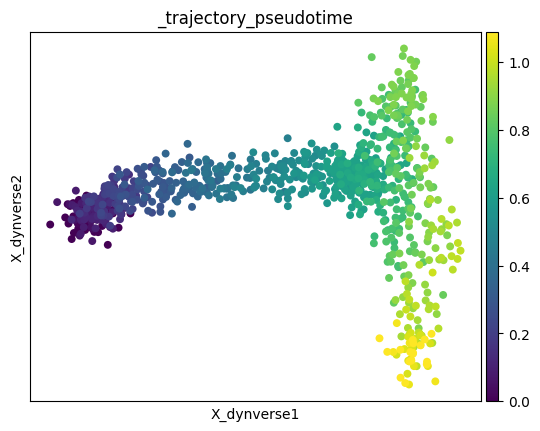

In [6]:
cafe.plot.plot_pseudotime_embedding(fadata, save=f"{img_dir}/plot_pseudotime.pdf") 

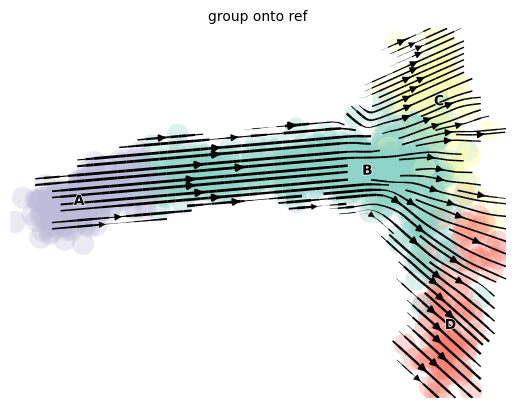

In [7]:
cafe.plot.plot_velocity(fadata, save=f"{img_dir}/plot_velocity.svg") # only can save svg